# Etapa 2 · Modelado con validación segura

**Proyecto Integrador de Aprendizaje Automático** · Donnys Torres Lozano · Maestría en Analítica de Datos, Universidad del Norte

Este cuaderno entrena el modelo final con un flujo sin fuga de datos: se dividen los datos antes de cualquier transformación, el preprocesamiento va dentro del `Pipeline`, los hiperparámetros se ajustan con `GridSearchCV` y el conjunto de prueba se usa una sola vez. Al final se exporta el modelo para la API.

In [1]:
import sys, warnings
sys.path.insert(0, "..")          # para importar el paquete src/ del proyecto
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import heart_ml as h

pd.set_option("display.max_colwidth", 90)
AZUL, NARANJA, GRIS = "#2a78d6", "#eb6834", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

## 1. División de los datos antes del escalado

In [2]:
df = h.cargar_datos()
X_train, X_test, y_train, y_test = h.dividir(df)       # 80 / 20 estratificado, semilla 42
pd.DataFrame({"Registros": [len(X_train), len(X_test)],
              "Con enfermedad": [int(y_train.sum()), int(y_test.sum())],
              "% con enfermedad": [round(100 * y_train.mean(), 1), round(100 * y_test.mean(), 1)]},
             index=["Entrenamiento", "Prueba"])

,Registros,Con enfermedad,% con enfermedad
Entrenamiento,733,405,55.3
Prueba,184,102,55.4


**Lectura.** Quedan 733 pacientes para entrenar y 184 para probar, con 55,3 % y 55,4 % de enfermos.

**Implicación predictiva.** La estratificación mantiene la misma proporción de clases en ambos conjuntos. En este punto los datos todavía no han sido escalados, imputados ni codificados.

**Acción recomendada.** No tocar el conjunto de prueba hasta la evaluación final.

## 2. Pipeline con GridSearchCV

In [3]:
from sklearn.ensemble import RandomForestClassifier

rejilla = {"clf__n_estimators": [200, 400], "clf__max_depth": [4, 8, None], "clf__min_samples_leaf": [1, 5]}
grid = h.train_pipeline(X_train, y_train, RandomForestClassifier(random_state=h.SEMILLA), rejilla)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"AUC en validación cruzada: {grid.best_score_:.3f} ± {grid.cv_results_['std_test_score'][grid.best_index_]:.3f}")
grid.best_estimator_

Mejores hiperparámetros: {'clf__max_depth': 8, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 400}
AUC en validación cruzada: 0.931 ± 0.018


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['Age','Sex','ChestPainType',...,'ExerciseAngina','Oldpeak','ST_Slope']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('col', ...), ('num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remai

In [4]:
res = pd.DataFrame(grid.cv_results_)[["param_clf__max_depth", "param_clf__min_samples_leaf",
                                      "param_clf__n_estimators", "mean_test_score", "std_test_score"]]
res.columns = ["max_depth", "min_samples_leaf", "n_estimators", "AUC CV (media)", "AUC CV (desv.)"]
res.sort_values("AUC CV (media)", ascending=False).round(4).reset_index(drop=True)

,max_depth,min_samples_leaf,n_estimators,AUC CV (media),AUC CV (desv.)
0,8,1,400,0.9309,0.0184
1,8,1,200,0.9302,0.0196
2,8,5,400,0.9300,0.0209
3,None,5,400,0.9295,0.0203
4,8,5,200,0.9292,0.0222
5,None,1,400,0.9290,0.0176
6,None,1,200,0.9286,0.0171
7,None,5,200,0.9286,0.0211
8,4,1,400,0.9277,0.0223
9,4,5,400,0.9276,0.0219


**Lectura.** La mejor combinación es de 400 árboles, profundidad máxima de 8 y mínimo de 1 muestra por hoja, con un AUC de 0,931 ± 0,018 en validación cruzada. Las 12 combinaciones de la rejilla quedan entre 0,927 y 0,931.

**Implicación predictiva.** El modelo es poco sensible a los hiperparámetros: la diferencia entre la mejor y la peor combinación es menor que la desviación entre pliegues. Ampliar la rejilla no daría una mejora apreciable.

**Acción recomendada.** Aceptar la configuración encontrada. El esfuerzo adicional rinde más en la calidad de los datos que en el ajuste fino.

## 3. Evaluación en el conjunto de prueba

In [5]:
modelo = grid.best_estimator_
m_train, m_test = h.evaluar(modelo, X_train, y_train), h.evaluar(modelo, X_test, y_test)
pd.DataFrame({"Entrenamiento": m_train, "Prueba": m_test}).drop("matriz").astype(float).round(3)

,Entrenamiento,Prueba
AUC,0.996,0.931
Exactitud,0.966,0.880
Precisión,0.961,0.885
Sensibilidad,0.978,0.902
F1,0.969,0.893


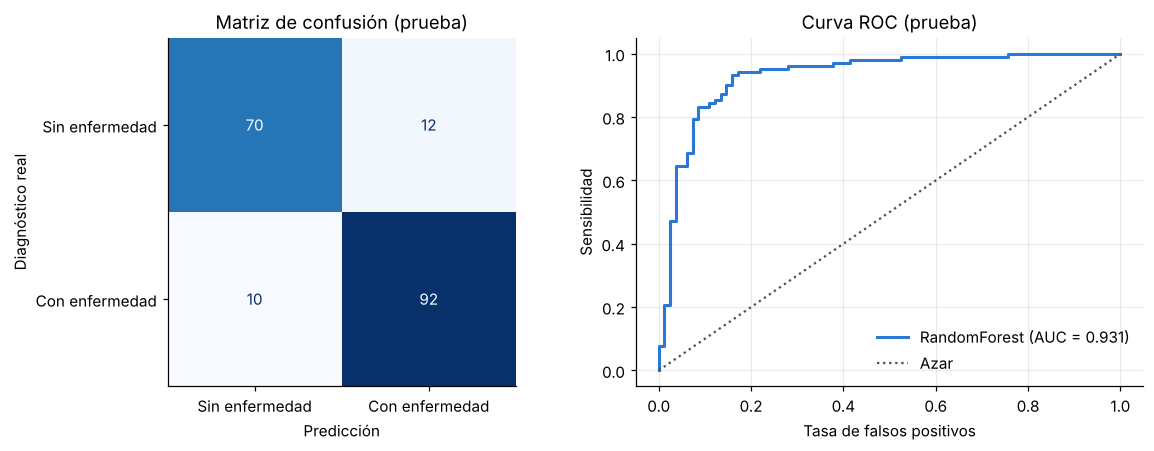

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve

fig, (e1, e2) = plt.subplots(1, 2, figsize=(11, 4.2))
ConfusionMatrixDisplay(m_test["matriz"], display_labels=["Sin enfermedad", "Con enfermedad"]).plot(
    ax=e1, cmap="Blues", colorbar=False)
e1.set_title("Matriz de confusión (prueba)"); e1.set_xlabel("Predicción"); e1.set_ylabel("Diagnóstico real"); e1.grid(False)
fpr, tpr, _ = roc_curve(y_test, modelo.predict_proba(X_test)[:, 1])
e2.plot(fpr, tpr, color=AZUL, linewidth=2, label=f"RandomForest (AUC = {m_test['AUC']:.3f})")
e2.plot([0, 1], [0, 1], linestyle=":", color=GRIS, label="Azar")
e2.set_title("Curva ROC (prueba)"); e2.set_xlabel("Tasa de falsos positivos"); e2.set_ylabel("Sensibilidad")
e2.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()

**Lectura.** En prueba el modelo obtiene un AUC de 0,931, exactitud de 0,880, precisión de 0,885, sensibilidad de 0,902 y F1 de 0,893. La matriz de confusión muestra 70 verdaderos negativos, 12 falsos positivos, 10 falsos negativos y 92 verdaderos positivos. En entrenamiento el AUC es de 0,996 y la exactitud de 0,966.

**Implicación predictiva.** El AUC de prueba (0,931) coincide con el de validación cruzada (0,931), lo que confirma que la estimación era confiable y que no hubo fuga. La diferencia con el entrenamiento (0,996) es propia del RandomForest, que memoriza parte de los datos con que se entrena; por eso la métrica de entrenamiento no debe reportarse como desempeño. El error crítico son los 10 falsos negativos, cerca del 10 % de los enfermos.

**Acción recomendada.** Reportar 0,931 como AUC esperado. Si el modelo se usa para tamizaje, conviene bajar el umbral de 0,5 para reducir los falsos negativos, a cambio de más falsos positivos.

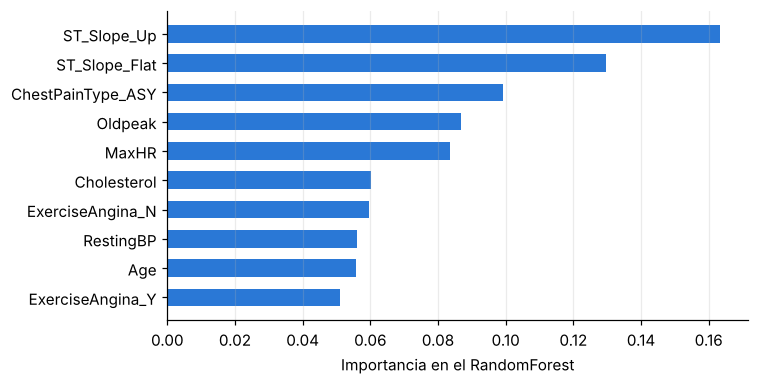

In [7]:
nombres = [n.split("__")[1] for n in modelo.named_steps["prep"].get_feature_names_out()]
imp = pd.Series(modelo.named_steps["clf"].feature_importances_, index=nombres).sort_values().tail(10)
fig, eje = plt.subplots(figsize=(7, 3.6))
eje.barh(imp.index, imp.values, color=AZUL, height=0.6)
eje.set_xlabel("Importancia en el RandomForest"); eje.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Lectura.** Las variables más importantes son la pendiente del ST ascendente (0,163) y plana (0,130), el dolor torácico asintomático (0,099), `Oldpeak` (0,087) y la frecuencia cardíaca máxima (0,084).

**Implicación predictiva.** El modelo decide sobre todo con las variables de la prueba de esfuerzo, lo que coincide con el análisis exploratorio. La importancia indica cuánto usa el modelo cada variable y no una relación causal.

**Acción recomendada.** Vigilar estas variables en el monitoreo de deriva, porque un cambio en su distribución afecta más al modelo.

## 4. Exportación del modelo

In [8]:
import joblib

joblib.dump(modelo, h.RAIZ / "app" / "model.joblib")
joblib.dump(modelo, h.RAIZ / "model.joblib")

# Comprobación: el modelo guardado predice igual que el modelo en memoria
recargado = joblib.load(h.RAIZ / "app" / "model.joblib")
print("Predicciones idénticas tras recargar:", bool((recargado.predict(X_test) == modelo.predict(X_test)).all()))

Predicciones idénticas tras recargar: True


El archivo `model.joblib` contiene el `Pipeline` completo, es decir, el preprocesamiento y el RandomForest. De esta forma la API recibe los datos crudos del paciente, con los mismos nombres de columna de `heart.csv`, y el propio modelo se encarga de imputar, escalar y codificar. El mismo resultado se obtiene desde la terminal con `python train.py`.